In [13]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

In [14]:
class BrainMRIDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx]) 
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask'].float().unsqueeze(0) / 255.0 
            
        return image, mask

class BrainDataModule(pl.LightningDataModule):
    def __init__(self, data_dir, batch_size=16):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])

    def setup(self, stage=None):
        full_dataset = BrainMRIDataset(
            os.path.join(self.data_dir, "images"),
            os.path.join(self.data_dir, "masks"),
            transform=self.transform
        )
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        self.train_ds, self.val_ds = random_split(full_dataset, [train_size, val_size])

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=2)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size, num_workers=2)

In [15]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        
        self.bottleneck = DoubleConv(512, 1024)
        
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        
        self.final_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        
        b = self.bottleneck(self.pool(s4))
        
        d4 = self.dec4(torch.cat([self.up4(b), s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))
        
        return self.final_conv(d1)

In [16]:
class SegmentationModel(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = UNet()
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.model(x)

    def dice_score(self, pred, target):
        smooth = 1e-6
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()
        intersection = (pred * target).sum()
        return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

    def training_step(self, batch, batch_idx):
        img, mask = batch
        out = self(img)
        loss = self.criterion(out, mask)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        img, mask = batch
        out = self(img)
        loss = self.criterion(out, mask)
        dice = self.dice_score(out, mask)
        self.log_dict({"val_loss": loss, "val_dice": dice}, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-4)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model     | UNet              | 31.0 M | train | 0    
1 | criterion | BCEWithLogitsLoss | 0      | train | 0    
----------------------------------------------------------------
31.0 M    Trainable params
0         Non-trainable params
31.0 M    Total params
124.174   Total estimated model params size (MB)
80        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2216992].


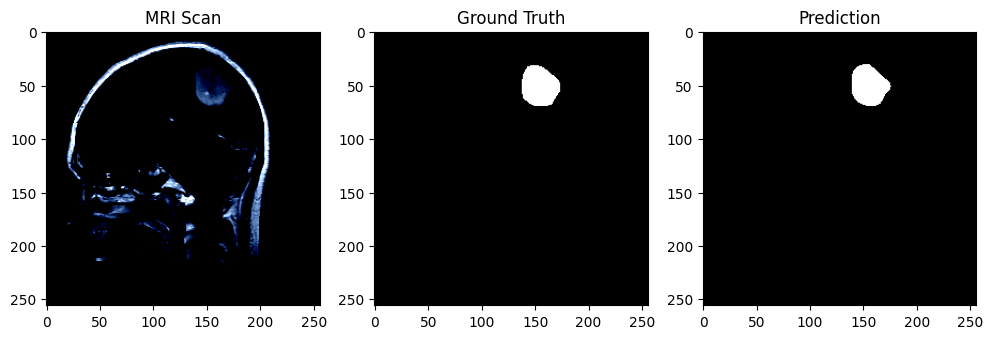

In [17]:
# 1. Initialize Data and Model
dm = BrainDataModule(data_dir="dataset", batch_size=8)
model = SegmentationModel()

# 2. Trainer Setup
trainer = pl.Trainer(
    max_epochs=20,
    accelerator="auto", 
    devices=1,
    callbacks=[ModelCheckpoint(monitor="val_dice", mode="max")]
)

# 3. Start Training
trainer.fit(model, dm)

# 4. Result Generation & Evaluation
model.eval()
test_img, test_mask = next(iter(dm.val_dataloader()))
with torch.no_grad():
    prediction = torch.sigmoid(model(test_img))
    prediction = (prediction > 0.5).float()

# Visualization
idx = 0
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(test_img[idx].permute(1,2,0).cpu()); plt.title("MRI Scan")
plt.subplot(1, 3, 2); plt.imshow(test_mask[idx].squeeze().cpu(), cmap='gray'); plt.title("Ground Truth")
plt.subplot(1, 3, 3); plt.imshow(prediction[idx].squeeze().cpu(), cmap='gray'); plt.title("Prediction")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4831371].


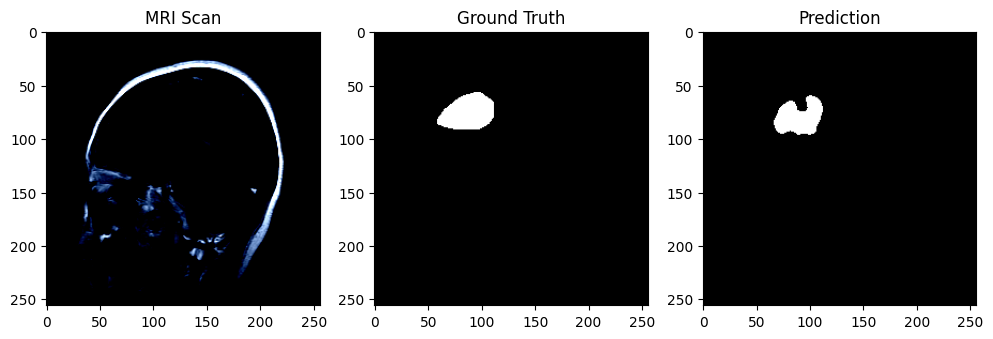

In [18]:
# Visualization
idx = 4
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(test_img[idx].permute(1,2,0).cpu()); plt.title("MRI Scan")
plt.subplot(1, 3, 2); plt.imshow(test_mask[idx].squeeze().cpu(), cmap='gray'); plt.title("Ground Truth")
plt.subplot(1, 3, 3); plt.imshow(prediction[idx].squeeze().cpu(), cmap='gray'); plt.title("Prediction")
plt.show()